<a href="https://colab.research.google.com/github/dieguito1331/cienciaDatos/blob/master/UCEMA/06 - NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Procesamiento de Lenguaje Natural (NLP) aplicado a opiniones de clientes

En esta notebook vamos a trabajar un caso simple de **NLP aplicado a negocio**:

- Simular un dataset de **comentarios de clientes** sobre un servicio.
- Explorar de manera básica el texto.
- Preparar el texto (preprocesamiento).
- Construir representaciones numéricas de los textos (bolsa de palabras / TF-IDF).
- Entrenar un **modelo de clasificación** para predecir satisfacción.
- Agregar una métrica de "nivel de reclamos" por fecha, que luego podría usarse en modelos de **series de tiempo**.

> Nota: el foco no es hacer el mejor modelo del mundo, sino **entender el flujo completo**:  
> texto → features → modelo → métrica agregada para negocio.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
pd.set_option("display.max_colwidth", 200)


## 🧪 Generación de un dataset sintético de opiniones

Vamos a simular un dataset con:

- `fecha`: día de la opinión
- `comentario`: texto libre del cliente
- `satisfecho`: 1 si el cliente está satisfecho, 0 si está insatisfecho

Los textos van a ser frases cortas en español, armadas a partir de plantillas positivas y negativas.
Esto nos permite:

- Tener un dataset realista pero controlado.
- Probar fácilmente el modelo de clasificación.
- Crear métricas agregadas (por día o semana).


In [12]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Queremos ~1000 comentarios → 100 días * 10 comentarios/día = 1000
fechas = pd.date_range("2024-01-01", periods=100, freq="D")
n_por_dia = 10  # cantidad de opiniones por día

positivas = [
    "el servicio es excelente y muy rápido",
    "estoy muy satisfecho con la atención",
    "todo funcionó perfecto, muy recomendable",
    "muy buena experiencia, sin problemas",
    "la plataforma es fácil de usar y confiable",
    "me resolvieron el problema enseguida",
    "la calidad del servicio es muy buena",
    "la atención al cliente fue excelente",
]

negativas = [
    "el servicio es muy malo y tarda mucho",
    "estoy muy disconforme con la atención",
    "tuve muchos problemas para usar la plataforma",
    "la experiencia fue pésima y lenta",
    "la respuesta fue muy mala y tardía",
    "no resolvieron mi problema, muy frustrante",
    "es un servicio poco confiable y lento",
    "la atención al cliente fue terrible",
]

# Comentarios más neutros / ambiguos que pueden ir para ambos lados
neutras = [
    "el servicio es aceptable pero podría mejorar",
    "la experiencia fue normal, nada especial",
    "a veces funciona bien y otras no tanto",
    "no estuvo mal pero esperaba algo mejor",
    "la atención fue correcta, sin destacar",
    "el servicio cumple pero con algunos detalles",
]

data = []
for fecha in fechas:
    for _ in range(n_por_dia):
        # Elegimos tipo de comentario (pos, neg, neutro)
        tipo = np.random.choice(["pos", "neg", "neu"], p=[0.45, 0.35, 0.20])

        if tipo == "pos":
            comentario = np.random.choice(positivas)
            etiqueta = 1  # satisfecho
        elif tipo == "neg":
            comentario = np.random.choice(negativas)
            etiqueta = 0  # insatisfecho
        else:  # neutro
            comentario = np.random.choice(neutras)
            # comentario ambiguo: la etiqueta puede ser 0 o 1
            etiqueta = np.random.choice([0, 1], p=[0.5, 0.5])

        # Introducimos ruido de etiquetas (simular errores / ambigüedad)
        # En ~15% de los casos, damos vuelta la etiqueta
        if np.random.rand() < 0.15:
            etiqueta = 1 - etiqueta

        data.append([fecha, comentario, etiqueta])

df = pd.DataFrame(data, columns=["fecha", "comentario", "satisfecho"])

print(df.shape)
df.head(10)


(1000, 3)


,fecha,comentario,satisfecho
0,2024-01-01,la plataforma es fácil de usar y confiable,1
1,2024-01-01,la respuesta fue muy mala y tardía,0
2,2024-01-01,"todo funcionó perfecto, muy recomendable",1
3,2024-01-01,la atención al cliente fue excelente,1
4,2024-01-01,estoy muy satisfecho con la atención,1
5,2024-01-01,"la experiencia fue normal, nada especial",0
6,2024-01-01,me resolvieron el problema enseguida,0
7,2024-01-01,"todo funcionó perfecto, muy recomendable",1
8,2024-01-01,"muy buena experiencia, sin problemas",1
9,2024-01-01,me resolvieron el problema enseguida,1


## 👀 Exploración rápida del dataset

Antes de hacer cualquier modelo, miramos:

- Ejemplos de comentarios.
- Distribución de satisfechos vs insatisfechos.
- Un par de días al azar para ver variedad de opiniones.


In [13]:
print("Shape del dataset:", df.shape)
print("\nDistribución de la variable 'satisfecho':")
print(df["satisfecho"].value_counts(normalize=True).rename("proporción"))

print("\nMuestreo de comentarios:")
df.sample(10, random_state=42)


Shape del dataset: (1000, 3)

Distribución de la variable 'satisfecho':
satisfecho
1    0.546
0    0.454
Name: proporción, dtype: float64

Muestreo de comentarios:


,fecha,comentario,satisfecho
521,2024-02-22,la plataforma es fácil de usar y confiable,1
737,2024-03-14,la atención al cliente fue excelente,1
740,2024-03-15,estoy muy satisfecho con la atención,1
660,2024-03-07,el servicio es muy malo y tarda mucho,1
411,2024-02-11,a veces funciona bien y otras no tanto,0
678,2024-03-08,"muy buena experiencia, sin problemas",1
626,2024-03-03,"todo funcionó perfecto, muy recomendable",1
513,2024-02-21,la plataforma es fácil de usar y confiable,1
859,2024-03-26,estoy muy disconforme con la atención,0
136,2024-01-14,la respuesta fue muy mala y tardía,0


## 🧹 Preprocesamiento básico de texto

Para este ejemplo vamos a hacer un preprocesamiento simple:

- Pasar todo a minúsculas.
- Eliminar algunos signos de puntuación básicos.
- (Opcional) Quitar tildes o stopwords — en este ejemplo no es estrictamente necesario.

Luego, vamos a usar `CountVectorizer` y `TfidfVectorizer`, que:

- Convierten texto en vectores numéricos.
- Cada columna representa una palabra (o n-grama).
- El valor puede ser:
  - Conteo (CountVectorizer)
  - Importancia ponderada por frecuencia inversa (TF-IDF)


In [14]:
import re

def limpiar_texto(texto: str) -> str:
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñü0-9\s]", " ", texto)  # dejamos letras, números y espacios
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["comentario_limpio"] = df["comentario"].apply(limpiar_texto)
df[["comentario", "comentario_limpio"]].head(10)


,comentario,comentario_limpio
0,la plataforma es fácil de usar y confiable,la plataforma es fácil de usar y confiable
1,la respuesta fue muy mala y tardía,la respuesta fue muy mala y tardía
2,"todo funcionó perfecto, muy recomendable",todo funcionó perfecto muy recomendable
3,la atención al cliente fue excelente,la atención al cliente fue excelente
4,estoy muy satisfecho con la atención,estoy muy satisfecho con la atención
5,"la experiencia fue normal, nada especial",la experiencia fue normal nada especial
6,me resolvieron el problema enseguida,me resolvieron el problema enseguida
7,"todo funcionó perfecto, muy recomendable",todo funcionó perfecto muy recomendable
8,"muy buena experiencia, sin problemas",muy buena experiencia sin problemas
9,me resolvieron el problema enseguida,me resolvieron el problema enseguida


## 🔢 De texto a números: CountVectorizer y TF-IDF

Vamos a convertir los comentarios en features numéricos usando dos enfoques:

1. **CountVectorizer**  
   - Cada columna es una palabra.  
   - El valor es el número de veces que aparece la palabra en el comentario.

2. **TfidfVectorizer**  
   - Similar a CountVectorizer, pero pondera las palabras en función de:
     - cuántas veces aparecen en un comentario, y
     - cuán raras o comunes son en todo el corpus.
   - Las palabras muy frecuentes pero poco informativas (ej: “el”, “la”, “es”) tienden a tener menor peso.

Para el modelo de clasificación usaremos **TF-IDF + Regresión Logística**.


In [15]:
X = df["comentario_limpio"]
y = df["satisfecho"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=2000,  # limitar cantidad de features
    ngram_range=(1, 2)  # unigrams y bigrams
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

X_train_vec.shape, X_test_vec.shape


((800, 167), (200, 167))

## 🤖 Modelo de clasificación: Regresión Logística

Vamos a entrenar un modelo de **Regresión Logística** para predecir:

- `1` → comentario satisfecho  
- `0` → comentario insatisfecho  

La idea no es lograr el modelo perfecto, sino mostrar el flujo:

1. Texto → TF-IDF → Matriz numérica.
2. Entrenamos la regresión logística.
3. Evaluamos métricas básicas.


In [16]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_vec, y_train)

y_pred = modelo.predict(X_test_vec)

print(classification_report(y_test, y_pred, digits=3))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0      0.784     0.758     0.771        91
           1      0.804     0.826     0.814       109

    accuracy                          0.795       200
   macro avg      0.794     0.792     0.793       200
weighted avg      0.795     0.795     0.795       200

Matriz de confusión:
[[69 22]
 [19 90]]


## 🧩 ¿Qué palabras son más importantes para el modelo?

Una ventaja de los modelos lineales (como la regresión logística) es que podemos inspeccionar sus coeficientes.

- Coeficientes positivos: asociados a **mayor probabilidad de satisfacción (1)**.
- Coeficientes negativos: asociados a **mayor probabilidad de insatisfacción (0)**.

Vamos a ver algunas de las palabras o n-gramas más influyentes.


In [17]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = modelo.coef_[0]

# Top 15 palabras asociadas a satisfacción (coeficiente alto)
top_pos_idx = np.argsort(coefs)[-15:]
top_pos_words = feature_names[top_pos_idx]
top_pos_values = coefs[top_pos_idx]

# Top 15 palabras asociadas a insatisfacción (coeficiente bajo)
top_neg_idx = np.argsort(coefs)[:15]
top_neg_words = feature_names[top_neg_idx]
top_neg_values = coefs[top_neg_idx]

print("Palabras más asociadas a satisfacción (coeficiente positivo):")
for w, c in zip(top_pos_words, top_pos_values):
    print(f"{w:25s}  {c:.3f}")

print("\nPalabras más asociadas a insatisfacción (coeficiente negativo):")
for w, c in zip(top_neg_words, top_neg_values):
    print(f"{w:25s}  {c:.3f}")


Palabras más asociadas a satisfacción (coeficiente positivo):
muy recomendable           0.564
funcionó                   0.564
funcionó perfecto          0.564
perfecto muy               0.564
sin                        0.662
sin problemas              0.770
buena experiencia          0.770
experiencia sin            0.770
muy satisfecho             0.934
satisfecho con             0.934
satisfecho                 0.934
buena                      1.083
muy buena                  1.083
excelente                  1.831
fue excelente              1.885

Palabras más asociadas a insatisfacción (coeficiente negativo):
fue terrible               -1.691
terrible                   -1.691
muy disconforme            -1.202
disconforme                -1.202
disconforme con            -1.202
lento                      -0.683
confiable lento            -0.683
poco                       -0.683
poco confiable             -0.683
un servicio                -0.683
servicio poco              -0.683
es u

## 📈 De NLP a métrica de negocio: nivel de reclamos por día

Hasta ahora trabajamos a nivel **comentario** (fila a fila).

Ahora queremos construir una métrica agregada que nos sirva como señal para:
- monitorear evolución en el tiempo, y
- eventualmente alimentar un modelo de **series de tiempo** (forecasting).

Podemos hacer, por ejemplo:

- Por día, contar:
  - cantidad de comentarios,
  - cantidad de insatisfechos (`satisfecho = 0`),
  - porcentaje de insatisfechos.

Esto nos da una serie temporal diaria de “nivel de reclamos”.


In [18]:
df["es_insatisfecho"] = 1 - df["satisfecho"]

df_diario = (
    df.groupby("fecha")
      .agg(
          total_comentarios=("comentario", "count"),
          insatisfechos=("es_insatisfecho", "sum")
      )
      .assign(pct_insatisfechos=lambda d: d["insatisfechos"] / d["total_comentarios"])
)

df_diario.head()


,total_comentarios,insatisfechos,pct_insatisfechos
fecha,,,
2024-01-01,10,3,0.3
2024-01-02,10,4,0.4
2024-01-03,10,3,0.3
2024-01-04,10,6,0.6
2024-01-05,10,7,0.7


from matplotlib import pyplot as plt
_df_0['insatisfechos'].plot(kind='hist', bins=20, title='insatisfechos')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['pct_insatisfechos'].plot(kind='hist', bins=20, title='pct_insatisfechos')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='insatisfechos', y='pct_insatisfechos', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['total_comentarios']
  ys = series['insatisfechos']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('total_comentarios', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('total_comentarios')
_ = plt.ylabel('insatisfechos')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['total_comentarios']
  ys = series['pct_insatisfechos']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_4.sort_values('total_comentarios', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('total_comentarios')
_ = plt.ylabel('pct_insatisfechos')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['total_comentarios']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'total_comentarios'}, axis=1)
              .sort_values('total_comentarios', ascending=True))
  xs = counted['total_comentarios']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_5.sort_values('total_comentarios', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('total_comentarios')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_6['insatisfechos'].plot(kind='line', figsize=(8, 4), title='insatisfechos')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_7['pct_insatisfechos'].plot(kind='line', figsize=(8, 4), title='pct_insatisfechos')
plt.gca().spines[['top', 'right']].set_visible(False)

## 📊 Visualización: evolución del porcentaje de insatisfechos

Vamos a graficar la serie diaria del **porcentaje de comentarios insatisfechos**.

Esta serie podría utilizarse:

- Como input (feature) en un modelo de forecasting de ventas.
- Como métrica de monitoreo de experiencia de cliente.
- Como señal para detectar períodos problemáticos (ej: lanzamientos, incidentes).


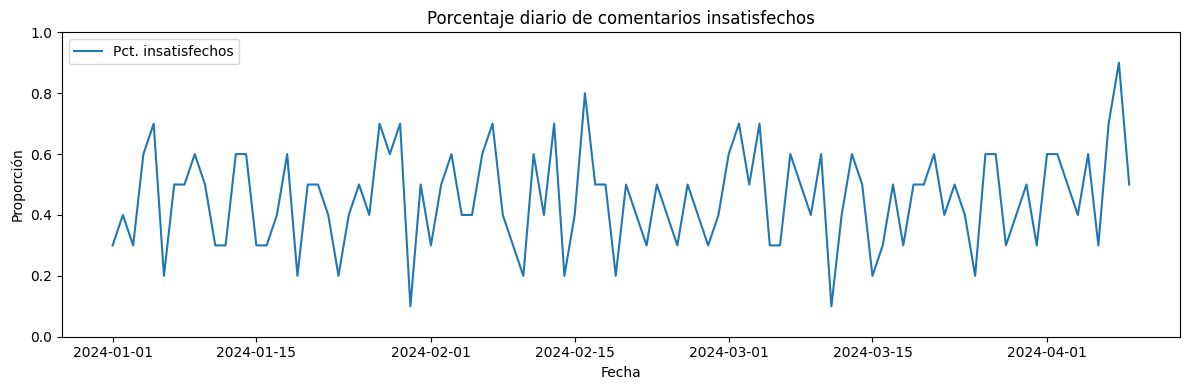

In [19]:
plt.figure(figsize=(12,4))
plt.plot(df_diario.index, df_diario["pct_insatisfechos"], label="Pct. insatisfechos")
plt.title("Porcentaje diario de comentarios insatisfechos")
plt.xlabel("Fecha")
plt.ylabel("Proporción")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


# ✅ Resumen de la notebook

En esta notebook vimos un flujo completo de **NLP aplicado a negocio**:

1. Generamos un dataset sintético de opiniones de clientes.
2. Exploramos ejemplos y la distribución de satisfacción.
3. Preprocesamos el texto (limpieza básica).
4. Convertimos los textos a representaciones numéricas (TF-IDF).
5. Entrenamos un modelo de clasificación (Regresión Logística).
6. Inspeccionamos qué palabras estaban más asociadas con satisfacción e insatisfacción.
7. Construimos una métrica diaria de "nivel de reclamos" (porcentaje de insatisfechos).
8. Visualizamos la serie de esa métrica en el tiempo.

Este tipo de flujo permite:

- Conectar el mundo de **texto** con el mundo de **series de tiempo**.
- Crear features de experiencia de cliente que luego se pueden utilizar para:
  - Pronosticar ventas.
  - Explicar caídas en la conversión.
  - Detectar períodos de crisis o incidentes.

En una siguiente etapa, podríamos:

- Integrar esta métrica con un modelo de forecasting (Holt-Winters, SARIMAX, Prophet, modelos de Deep Learning).
- Usar embeddings más avanzados (modelos pre-entrenados) en lugar de TF-IDF.
- Hacer análisis de temas (topic modeling) para entender *de qué se quejan los clientes*.

---
